In [1]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Load Dataset

df = pd.read_csv('bbc_news_dataset.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ArticleId  1490 non-null   int64
 1   Text       1490 non-null   str  
 2   Category   1490 non-null   str  
dtypes: int64(1), str(2)
memory usage: 3.2 MB


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [3]:
#Separating features and Labels
X = df['Text']
y = df['Category']

In [4]:
category_names = df['Category'].unique()
print(category_names)

value_count = df['Category'].value_counts()
print(value_count)

<ArrowStringArray>
['business', 'tech', 'politics', 'sport', 'entertainment']
Length: 5, dtype: str
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


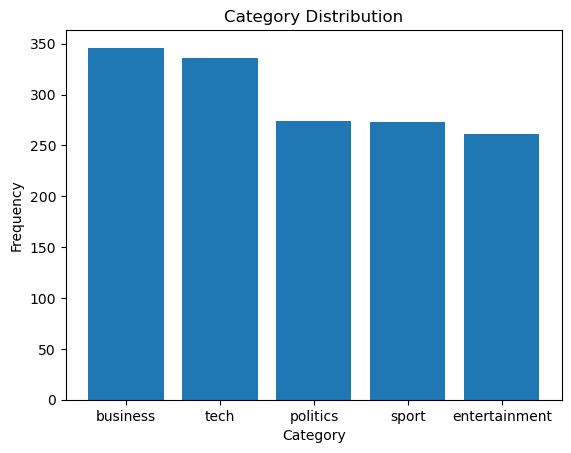

In [5]:
plt.bar(x=category_names, height=value_count)
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

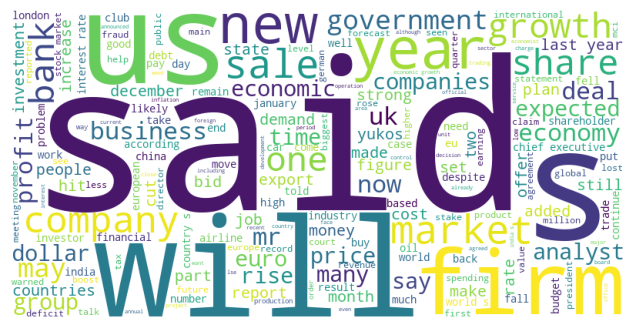

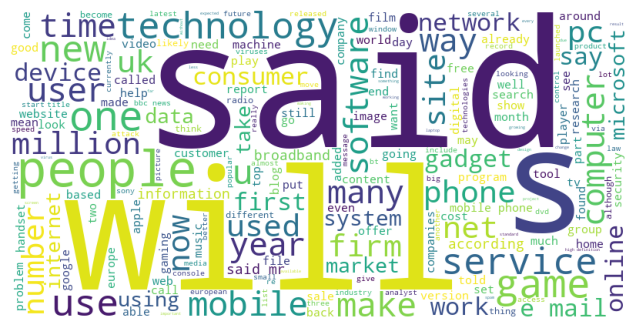

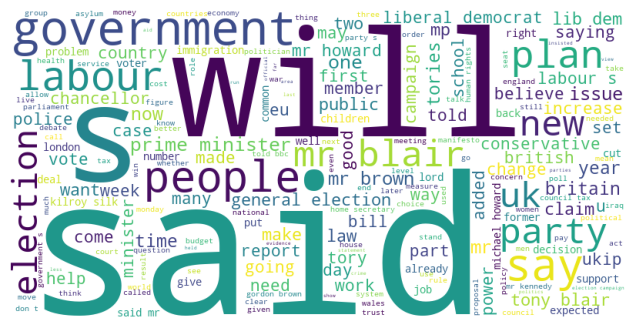

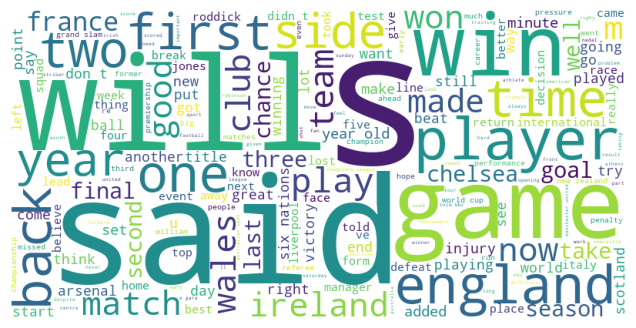

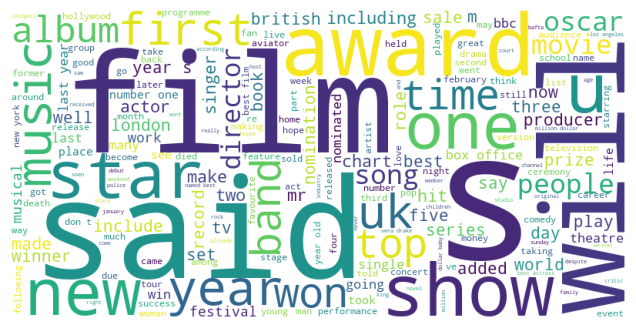

In [6]:
from wordcloud import WordCloud
for category in category_names:
    text = " ".join(df[df['Category'] ==  category]['Text'].values)
    wc = WordCloud(width = 800, height = 400, background_color='white',).generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

In [7]:
#splitting the data for training and testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
#building model
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()

)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print(classification_report(y_test, y_pred))

Accuracy : 0.9563758389261745
Precision: 0.9574896655178124
Recall   : 0.9563758389261745
F1-Score : 0.9562904295627416
               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



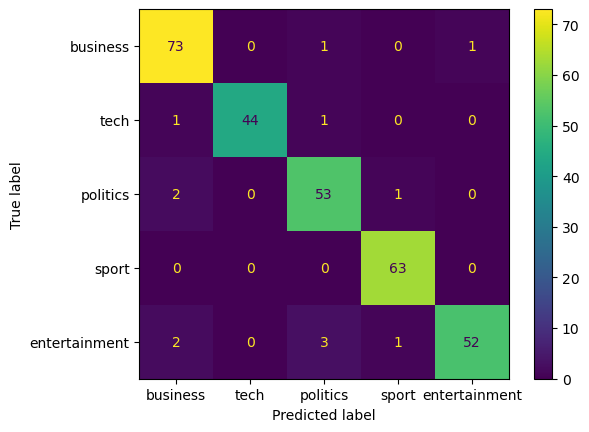

In [10]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay\

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=category_names).plot()

In [11]:
#testing with New article

texts = ['ronaldo scored 2 goal in fifa world cup']
prediction = model.predict(texts)
print(prediction)

['sport']


In [12]:
import joblib

joblib.dump(model, 'model.joblib')
print('Success')

Success


In [13]:
#playing with hyperparameter of tfidfvectorizer

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

parameters = [
    {"max_features": 1000, "ngram_range": (1,1), "min_df": 1},
    {"max_features": 3000, "ngram_range": (1,2), "min_df": 2},
    {"max_features": 5000, "ngram_range": (1,3), "min_df": 5}
]
for parameter in parameters:
    model = make_pipeline(
        TfidfVectorizer(
        stop_words='english',
        max_features=parameter["max_features"],
        ngram_range=parameter["ngram_range"],
        min_df=parameter["min_df"]
    ),
        MultinomialNB()

    )
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.9765100671140939


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

     business       0.97      0.97      0.97        75
entertainment       1.00      1.00      1.00        46
     politics       0.95      0.95      0.95        56
        sport       0.98      1.00      0.99        63
         tech       0.98      0.97      0.97        58

     accuracy                           0.98       298
    macro avg       0.98      0.98      0.98       298
 weighted avg       0.98      0.98      0.98       298



## classifying at least five custom news articles and record the predicted category

In [15]:
custom_news = [
    "India defeated Australia in the cricket world cup final.",
    "The government announced a new tax policy for small businesses.",
    "A new Marvel movie broke all box office records this weekend.",
    "Scientists developed an AI system to detect cancer earlier.",
    "Tesla unveiled its latest electric vehicle with improved battery life.",
    "The stock market saw a significant drop due to global economic concerns.",
    "A new study shows the benefits of a plant-based diet for heart health.",
]

prediction = model.predict(custom_news)

for news, category in zip(custom_news, prediction):
    print("News:", news)
    print("Predicted Category:", category)
    print()


#saving and reloading model

joblib.dump(model,"news_model.joblib")

model = joblib.load("news_model.joblib")

#prediction
text = ["the stoock market will rise today according to the chief officer of Nepse."]
model.predict(text)

News: India defeated Australia in the cricket world cup final.
Predicted Category: sport

News: The government announced a new tax policy for small businesses.
Predicted Category: business

News: A new Marvel movie broke all box office records this weekend.
Predicted Category: entertainment

News: Scientists developed an AI system to detect cancer earlier.
Predicted Category: tech

News: Tesla unveiled its latest electric vehicle with improved battery life.
Predicted Category: tech

News: The stock market saw a significant drop due to global economic concerns.
Predicted Category: business

News: A new study shows the benefits of a plant-based diet for heart health.
Predicted Category: business



array(['business'], dtype='<U13')

## Experiment with train-test split

In [16]:
splits = [0.3,0.2,0.1]

for split in splits:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=split,
        random_state=42)

    model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()

    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Train {(1-split)*100:.0f}% Test {split*100:.0f}%")
    print("Accuracy:",accuracy_score(y_test,y_pred))

Train 70% Test 30%
Accuracy: 0.9686800894854586
Train 80% Test 20%
Accuracy: 0.9563758389261745
Train 90% Test 10%
Accuracy: 0.959731543624161


## 5-fold cross validation

In [17]:
from sklearn.model_selection import cross_val_score
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
cross_val_score(model,X_train,y_train,scoring='accuracy',cv=5).mean()


np.float64(0.9672690833655638)

In [18]:
cross_val_score(model,X_train,y_train,scoring='accuracy', cv=5).std()

np.float64(0.009391768491566501)

## comparison between Multinomial Naive Bayes, Logistic Regression and support vector machine(SVM)

In [19]:
import time 
training_time = []
prediciton_time = []
accuracy_scores =[]

In [20]:
#Naive Bayes
naive_model = make_pipeline(
    TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3)),
    MultinomialNB()
    )
start = time.time()
naive_model.fit(X_train,y_train)
end = time.time()

training_time.append(end-start)

start = time.time()
y_pred = naive_model.predict(X_test)
end = time.time()
prediciton_time.append(end-start)
accuracy_scores.append(accuracy_score(y_test,y_pred))
print(f"Trainig time: {training_time[-1]:.4f}s")
print(f"Prediction time: {prediciton_time[-1]:.4f}s")
print(f"Accuracy score: {accuracy_scores}")


Trainig time: 1.8107s
Prediction time: 0.1423s
Accuracy score: [0.9731543624161074]


In [21]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
logistic_model = make_pipeline(
    TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3)),
    LogisticRegression()
)
start = time.time()
logistic_model.fit(X_train,y_train)
end = time.time()

training_time.append(end-start)

start = time.perf_counter()
y_pred = logistic_model.predict(X_test)
end = time.perf_counter()
prediciton_time.append(end-start)
accuracy_scores.append(accuracy_score(y_test,y_pred))

In [22]:
from sklearn.svm import LinearSVC
svc_model = make_pipeline(
    TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3)),
    LinearSVC()
    )
start = time.time()
svc_model.fit(X_train,y_train)
end = time.time()

training_time.append(end-start)

start = time.perf_counter()
y_pred = svc_model.predict(X_test)
end = time.perf_counter()
prediciton_time.append(end-start)
accuracy_scores.append(accuracy_score(y_test,y_pred))

In [23]:
pd.DataFrame({
    "training_time":training_time,
    "prediction_time":prediciton_time,
    "accuracy_score":accuracy_scores
},index=["MultinomialNB","LogisticRegression","LinearSVC"])

,training_time,prediction_time,accuracy_score
MultinomialNB,1.810748,0.142276,0.973154
LogisticRegression,2.157095,0.169801,0.973154
LinearSVC,2.027014,0.154038,0.976510


In [24]:
def compare_model(X, y):
    training_time = []
    prediciton_time = []
    accuracy_scores =[]
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    models_list = [MultinomialNB(),LogisticRegression(),LinearSVC()]
    for model in models_list:
        model = make_pipeline(
            TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3)),
            model
        )
        start = time.perf_counter()
        model.fit(X_train,y_train)
        end = time.perf_counter()
        
        training_time.append(end-start)
        
        start = time.perf_counter()
        y_pred = model.predict(X_test)
        end = time.perf_counter()
        
        prediciton_time.append(end-start)
        accuracy_scores.append(accuracy_score(y_test,y_pred))

    return training_time,prediciton_time,accuracy_scores

In [25]:
training_time,prediction_time,accuracy_scores = compare_model(X,y)


In [26]:
models_list = ["MultinomialNB","LogisticRegression","LinearSVC"]

pd.DataFrame({
        "training_time(s)":training_time,
        "prediction_time(s)":prediciton_time,
        "accuracy_score":accuracy_scores
        },index=models_list)

,training_time(s),prediction_time(s),accuracy_score
MultinomialNB,2.021303,0.142276,0.973154
LogisticRegression,2.316757,0.169801,0.973154
LinearSVC,1.828888,0.154038,0.976510


## News Recommendation Prototype that takes article from user and predict the category an display three similar articles from the same category using cosine similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

user_news = input("Enter a news article: ").strip()

if not user_news:
    raise ValueError("Please enter a non-empty news article.")

# Predict category
predicted_category = naive_model.predict([user_news])[0]

print("Predicted Category:", predicted_category)

# Filter articles from the same category
same_category = df[df["Category"] == predicted_category]
vectorizer = naive_model.named_steps["tfidfvectorizer"]
user_vector = vectorizer.transform([user_news])
category_vectors = vectorizer.transform(same_category["Text"])

# Cosine similarity
similarity = cosine_similarity(user_vector, category_vectors)

# Top 3 recommendations

top_indices = np.argsort(similarity[0])[:3][::-1]

print("\nTop 3 Similar Articles:\n")

for rank, index in enumerate(top_indices, start=1):
    print(f"{rank}.")
    print(same_category.iloc[index]["Text"])
    print()

Predicted Category: entertainment

Top 3 Similar Articles:

1.
elvis fans hold birthday bash elvis fans around the world have been marking the legendary singer s 70th birthday on saturday.  a three-day elvis convention took place in blackpool  england  over the weekend with the aim of finding the best european elvis impersonator. his graceland  tennessee  home was the focus for us celebrations with four days of events including a concert by the memphis symphony orchestra. elvis  single jailhouse rock became the uk s number one on sunday. fans in france celebrated with a tribute concert by elvis cover bands and a special exhibition of memorabilia is on display in bonn  germany.  jailhouse rock is now the 999th number one single in uk pop history. record company sonybmg are releasing elvis  18 number one singles at the rate of one a week in britain  complete with original artwork and a collector s box. hit single one night will follow next week - with the chance of becoming the 1 000th n